Olist e commerce data analysis - The objective of this project is to analyse customer distribution and order behaviour on the Olist e-commerce platform to derive meaningful business insights related to geography, order fulfilment, and delivery performance.

Data overview - This analysis uses the Olist Brazilian E-commerce dataset sourced from Kaggle. 
The dataset contains multiple tables related to customers, orders, payments, and logistics.
This project initially focuses on customer and order-level data.

In [46]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [47]:
os.listdir()

['Untitled1.ipynb',
 'olist_dashboard_data.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_ecommerce_analytics_quasi_poisson_poly_regs.py',
 'olist_customers_dataset.csv',
 'e-commerce delivery performance.ipynb',
 'olist_geolocation_dataset.csv',
 'olist_order_payments_dataset.csv',
 '.ipynb_checkpoints',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv']

In [48]:
import os
for file in os.listdir():
    print(file)

Untitled1.ipynb
olist_dashboard_data.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_ecommerce_analytics_quasi_poisson_poly_regs.py
olist_customers_dataset.csv
e-commerce delivery performance.ipynb
olist_geolocation_dataset.csv
olist_order_payments_dataset.csv
.ipynb_checkpoints
olist_order_reviews_dataset.csv
olist_products_dataset.csv


In [49]:
import pandas as pd
df = pd.read_csv("olist_customers_dataset.csv")
df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [50]:
df.shape

(99441, 5)

In [51]:
df.info

<bound method DataFrame.info of                             customer_id                customer_unique_id  \
0      06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1      18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2      4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3      b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4      4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   
...                                 ...                               ...   
99436  17ddf5dd5d51696bb3d7c6291687be6f  1a29b476fee25c95fbafc67c5ac95cf8   
99437  e7b71a9017aa05c9a7fd292d714858e8  d52a67c98be1cf6a5c84435bd38d095d   
99438  5e28dfe12db7fb50a4b2f691faecea5e  e9f50caf99f032f0bf3c55141f019d99   
99439  56b18e2166679b8a959d72dd06da27f9  73c2643a0a458b49f58cea58833b192e   
99440  274fa6071e5e17fe303b9748641082c8  84732c5050c01db9b23e19ba39899398   

       customer_zip_code_prefix          cu

Customer Geography Analysis - This section analyses the geographical distribution of customers across different Brazilian states.


In [52]:
# Count customers per state
df["customer_state"].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [53]:
# Top 10 states
df["customer_state"].value_counts().head(10)


customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

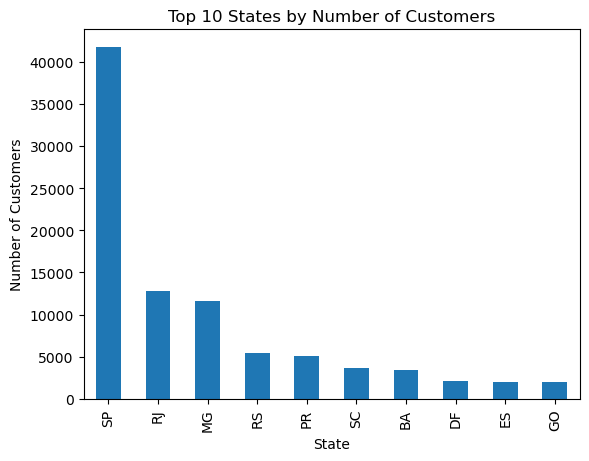

In [54]:
# Visualisation
df["customer_state"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 States by Number of Customers")
plt.xlabel("State")
plt.ylabel("Number of Customers")
plt.show()


Insight - São Paulo has the highest number of customers by a significant margin, indicating strong customer concentration in urban regions. Other states such as Rio de Janeiro and Minas Gerais also contribute substantially to the customer base.

## Order Behaviour Analysis

This section analyses the distribution of order statuses on the Olist platform to understand overall order fulfilment performance.

In [55]:
# Load orders dataset
orders = pd.read_csv("olist_orders_dataset.csv")
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [56]:
orders.shape


(99441, 8)

In [57]:
orders.info

<bound method DataFrame.info of                                order_id                       customer_id  \
0      e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1      53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2      47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3      949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4      ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                 ...                               ...   
99436  9c5dedf39a927c1b2549525ed64a053c  39bd1228ee8140590ac3aca26f2dfe00   
99437  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
99438  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
99439  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
99440  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

      order_status order_purchase_timestamp

In [58]:
orders["order_status"].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

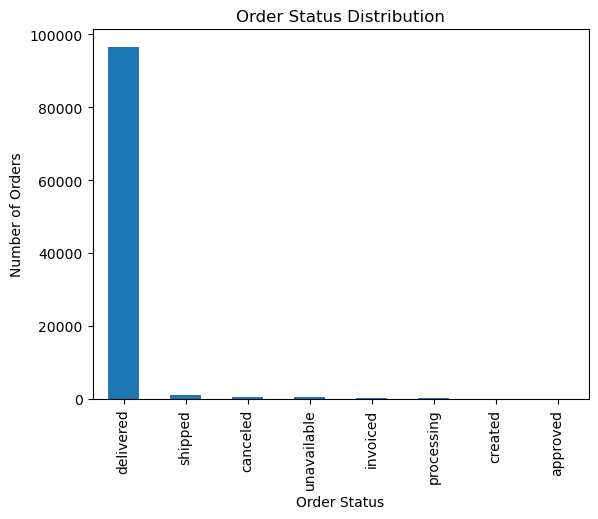

In [59]:
orders["order_status"].value_counts().plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.show()

The majority of orders on the Olist platform are successfully delivered, indicating a generally efficient order fulfilment process. However, cancellations and unavailable orders, although smaller in number, highlight areas where operational improvements may be required.

## Delivery Time Analysis

This section analyses the time taken to deliver orders to customers and evaluates overall delivery performance.

In [60]:
# Convert date columns to datetime format
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])

In [61]:
# Calculate delivery time in days
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days


In [62]:
# Calculate delivery time in days
orders["delivery_time_days"] = (
    orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]
).dt.days


In [63]:
# Summary statistics of delivery time
orders["delivery_time_days"].describe()


count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time_days, dtype: float64

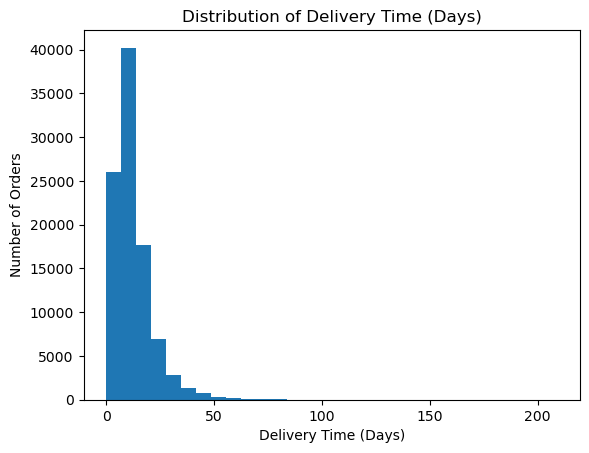

In [64]:
# Distribution of delivery time
orders["delivery_time_days"].dropna().plot(kind="hist", bins=30)
plt.title("Distribution of Delivery Time (Days)")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")
plt.show()


Most orders are delivered within a reasonable time frame, with the majority of deliveries occurring within a limited number of days. However, a small number of orders experience significantly longer delivery times, indicating potential logistics or regional challenges.

## Delivery Reliability Analysis

This section compares estimated delivery dates with actual delivery dates to evaluate whether orders were delivered on time or delayed.


In [65]:
# Convert estimated delivery date to datetime
orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [66]:
# Create delay indicator: 1 if delayed, 0 if on-time
orders["is_delayed"] = (
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
).astype(int)


In [67]:
# Count delayed vs on-time orders
orders["is_delayed"].value_counts()


is_delayed
0    91614
1     7827
Name: count, dtype: int64

In [68]:
# Percentage of delayed orders
orders["is_delayed"].value_counts(normalize=True) * 100


is_delayed
0    92.129001
1     7.870999
Name: proportion, dtype: float64

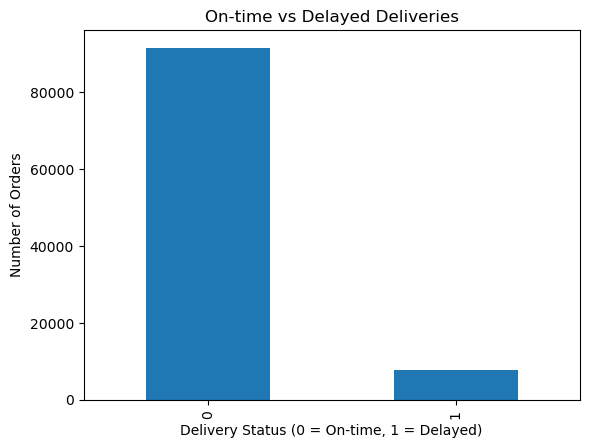

In [69]:
# Visualising delivery reliability
orders["is_delayed"].value_counts().plot(kind="bar")
plt.title("On-time vs Delayed Deliveries")
plt.xlabel("Delivery Status (0 = On-time, 1 = Delayed)")
plt.ylabel("Number of Orders")
plt.show()


While a majority of orders are delivered on time, a notable proportion of orders experience delivery delays. This indicates opportunities for improving delivery estimation accuracy and logistics performance.

## Customer–Order Combined Analysis

This section combines customer and order data to analyse regional patterns in order volume and delivery delays.

In [70]:
# Merge orders with customer data
orders_customers = orders.merge(
    df,
    on="customer_id",
    how="left"
)

In [71]:
orders_customers.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days,is_delayed,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [72]:
orders_customers.shape

(99441, 14)

In [73]:
# Number of orders per state
orders_customers["customer_state"].value_counts().head(10)

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: count, dtype: int64

In [74]:
# Average delay rate by state
orders_customers.groupby("customer_state")["is_delayed"].mean().sort_values(ascending=False).head(10)

customer_state
AL    0.230024
MA    0.188755
PI    0.153535
CE    0.146707
SE    0.145714
BA    0.135207
RJ    0.129474
TO    0.125000
ES    0.120020
PA    0.120000
Name: is_delayed, dtype: float64

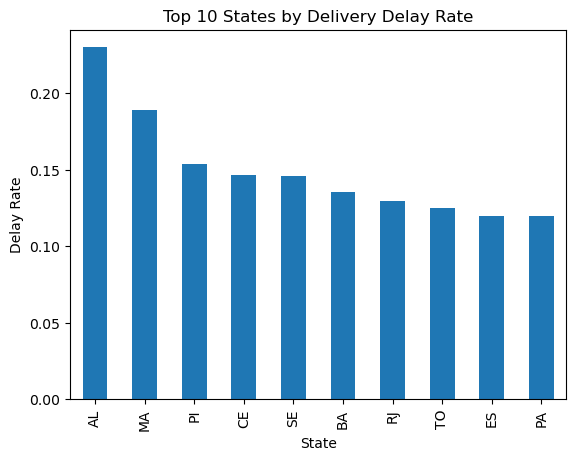

In [75]:
# Visualising delay rate by state
orders_customers.groupby("customer_state")["is_delayed"].mean().sort_values(ascending=False).head(10).plot(kind="bar")
plt.title("Top 10 States by Delivery Delay Rate")
plt.xlabel("State")
plt.ylabel("Delay Rate")
plt.show()


Delivery delays are not uniformly distributed across regions. Certain states exhibit significantly higher delay rates, suggesting regional logistics challenges and the need for targeted operational improvements.

## Executive Dashboard Overview

The dashboard is designed to provide decision-makers with a high-level view of order fulfilment performance and delivery reliability across regions.

### Dashboard Sections

1. Order Volume Overview  
2. Delivery Performance Metrics  
3. Delivery Reliability (On-time vs Delayed)  
4. Regional Delay Analysis  

In [76]:
# KPI Summary
kpi_summary = {
    "Total Orders": orders.shape[0],
    "Delivery Success Rate (%)": round(
        orders["order_status"].value_counts(normalize=True)["delivered"] * 100, 2
    ),
    "Average Delivery Time (Days)": round(
        orders["delivery_time_days"].mean(), 2
    ),
    "Delayed Orders (%)": round(
        orders["is_delayed"].mean() * 100, 2
    )
}

kpi_summary

{'Total Orders': 99441,
 'Delivery Success Rate (%)': np.float64(97.02),
 'Average Delivery Time (Days)': np.float64(12.09),
 'Delayed Orders (%)': np.float64(7.87)}

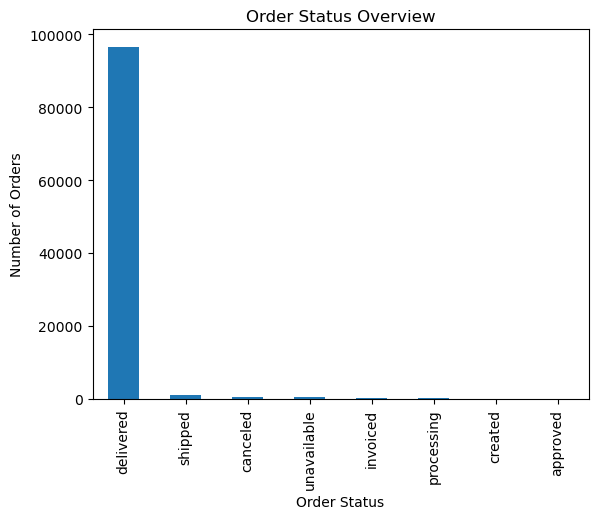

In [77]:
orders["order_status"].value_counts().plot(kind="bar")
plt.title("Order Status Overview")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")
plt.show()


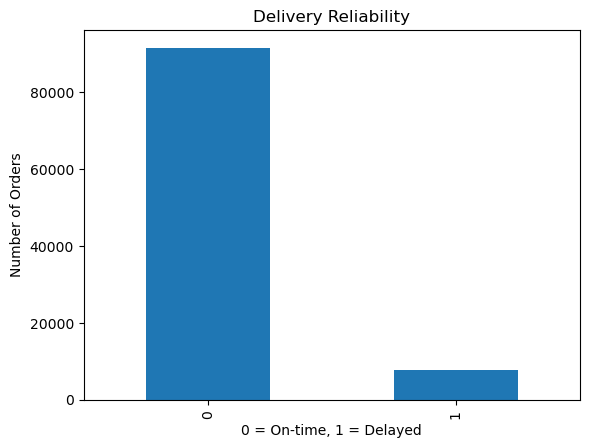

In [78]:
orders["is_delayed"].value_counts().plot(kind="bar")
plt.title("Delivery Reliability")
plt.xlabel("0 = On-time, 1 = Delayed")
plt.ylabel("Number of Orders")
plt.show()


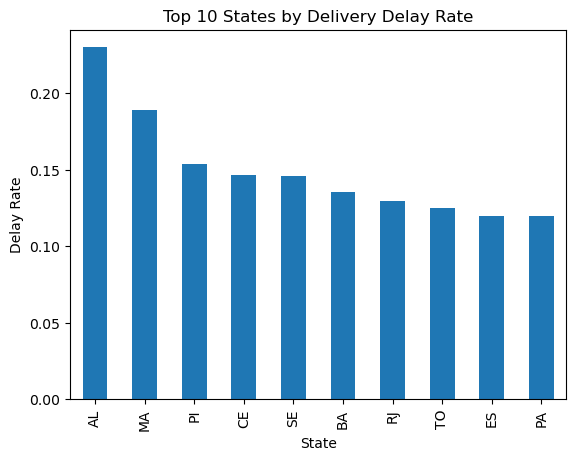

In [79]:
orders_customers.groupby("customer_state")["is_delayed"] \
    .mean() \
    .sort_values(ascending=False) \
    .head(10) \
    .plot(kind="bar")

plt.title("Top 10 States by Delivery Delay Rate")
plt.xlabel("State")
plt.ylabel("Delay Rate")
plt.show()


The dashboard highlights strong overall order fulfilment performance, with a high proportion of delivered orders. However, delivery delays are concentrated in specific regions, suggesting that operational inefficiencies are not uniform and require targeted regional interventions rather than platform-wide changes.


## Machine Learning Extension: Predicting Delivery Delays

This section explores whether historical order data can be used to predict the likelihood of an order being delivered late. The objective is to demonstrate how predictive analytics can support proactive logistics planning and operational decision-making.

In [80]:
# Filter delivered orders only
ml_data = orders_customers[
    orders_customers["order_status"] == "delivered"
].copy()

In [81]:
# Feature selection
ml_features = ml_data[[
    "customer_state",
    "delivery_time_days"
]]

target = ml_data["is_delayed"]


In [82]:
# One-hot encode state
ml_features_encoded = pd.get_dummies(ml_features, drop_first=True)


In [83]:
from sklearn.model_selection import train_test_split


In [84]:
ml_data = orders_customers[
    orders_customers["order_status"] == "delivered"
].copy()



In [85]:
ml_data = orders_customers[
    orders_customers["order_status"] == "delivered"
].copy()

In [86]:
# Select features for ML
ml_features = ml_data[[
    "customer_state",
    "delivery_time_days"
]]

# Target variable
target = ml_data["is_delayed"]

In [87]:
# Convert categorical variables into numeric form
ml_features_encoded = pd.get_dummies(ml_features, drop_first=True)


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    ml_features_encoded,
    target,
    test_size=0.3,
    random_state=42
)


In [89]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
ml_features.isna().sum()


customer_state        0
delivery_time_days    8
dtype: int64

In [90]:
# Remove rows with missing values
ml_data_clean = ml_data.dropna(subset=["delivery_time_days"])

ml_features = ml_data_clean[[
    "customer_state",
    "delivery_time_days"
]]

target = ml_data_clean["is_delayed"]

ml_features_encoded = pd.get_dummies(ml_features, drop_first=True)


In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    ml_features_encoded,
    target,
    test_size=0.3,
    random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [92]:
y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


NameError: name 'accuracy_score' is not defined

In [93]:
from sklearn.metrics import accuracy_score, classification_report


In [94]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Model Accuracy: 0.9544245188486922
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     26582
           1       0.82      0.57      0.67      2359

    accuracy                           0.95     28941
   macro avg       0.89      0.78      0.82     28941
weighted avg       0.95      0.95      0.95     28941



### Model Performance Interpretation

The classification metrics indicate an imbalance between delayed and non-delayed orders, which impacts recall and precision for the delayed class. While overall accuracy is high due to the dominance of on-time deliveries, the F1-score for delayed orders highlights the model’s moderate ability to correctly identify late deliveries. This model is therefore more suitable for risk flagging rather than precise delay prediction.


In [95]:
# Final dataset for Tableau dashboard
final_dashboard_data = orders_customers.copy()

# Export to CSV for Tableau
final_dashboard_data.to_csv(
    "olist_dashboard_data.csv",
    index=False
)

print("Dashboard CSV exported successfully")


Dashboard CSV exported successfully


In [96]:
import os
os.listdir()


['Untitled1.ipynb',
 'olist_dashboard_data.csv',
 'olist_orders_dataset.csv',
 'olist_order_items_dataset.csv',
 'olist_ecommerce_analytics_quasi_poisson_poly_regs.py',
 'olist_customers_dataset.csv',
 'e-commerce delivery performance.ipynb',
 'olist_geolocation_dataset.csv',
 'olist_order_payments_dataset.csv',
 '.ipynb_checkpoints',
 'olist_order_reviews_dataset.csv',
 'olist_products_dataset.csv']